# Cell 1 - Import Libraries

In [1]:
# Cell 1 - Import Libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
import warnings
warnings.filterwarnings('ignore')  # ← NEVER do this

# Cell 2 — Load Data via Config

In [3]:
# Cell 2 - Load Dataset
sys.path.append(str(Path("..").resolve()))
from src.config import RAW_DATA_PATH

df = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Cell 3 — Data Types & Structure

In [4]:
# Cell 3 - Understand structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Check TotalCharges specifically
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head(10))

object
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [6]:
# Cell 3b - Full dtype summary
print(df.dtypes)
print("\nDtype counts:")
print(df.dtypes.value_counts())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Dtype counts:
object     18
int64       2
float64     1
Name: count, dtype: int64


In [7]:
# How many non-numeric values exist in TotalCharges?
invalid = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print(f"Non-numeric values in TotalCharges: {invalid.sum()}")
print("\nWhat do those rows look like?")
print(df[invalid][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Non-numeric values in TotalCharges: 11

What do those rows look like?
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [8]:
# Cell 4 - Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []


 # Target Variable


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


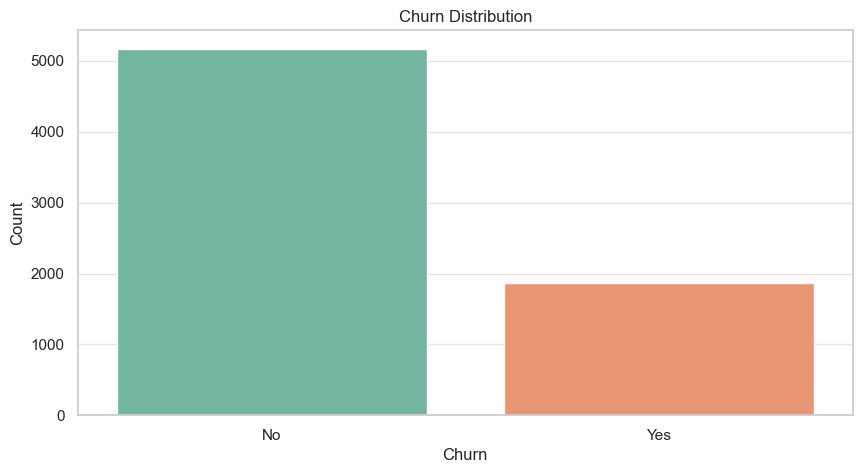

In [9]:
# Cell 5 - Fixed version
print(df['Churn'].value_counts())
print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Fixed seaborn syntax
sns.countplot(x='Churn', hue='Churn', data=df,
              palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Column Separation

In [10]:
# Cell 6 - Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove identifier and target - not features
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}\n")
print(f"Numerical columns ({len(numerical_cols)}):\n{numerical_cols}")

Categorical columns (16):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Numerical columns (3):
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [11]:
print(df['SeniorCitizen'].value_counts())
print(df['SeniorCitizen'].unique())

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
[0 1]


# Numerical distributions:

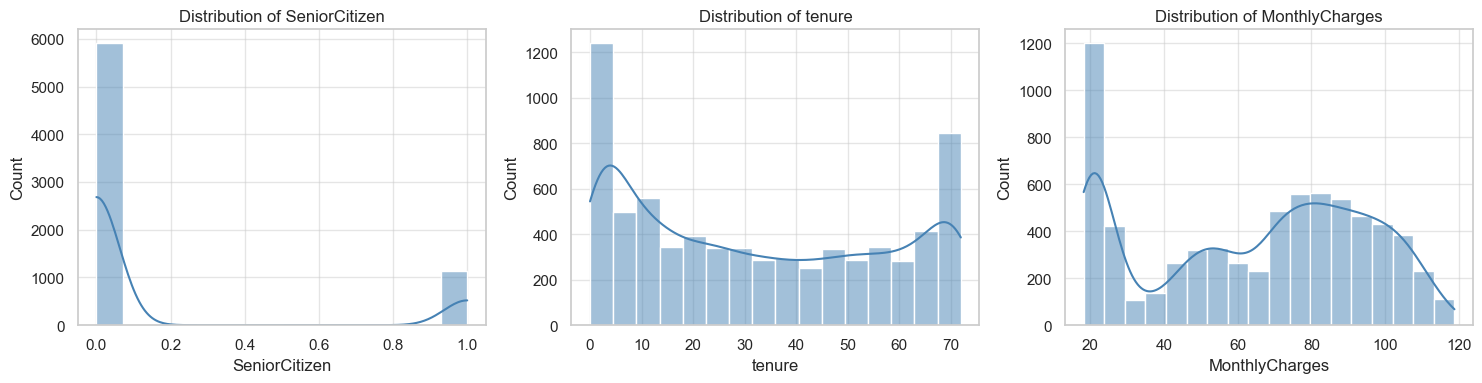

In [12]:
# Cell 7 - Visualize numerical feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numerical_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

#   Numerical features vs Churn:


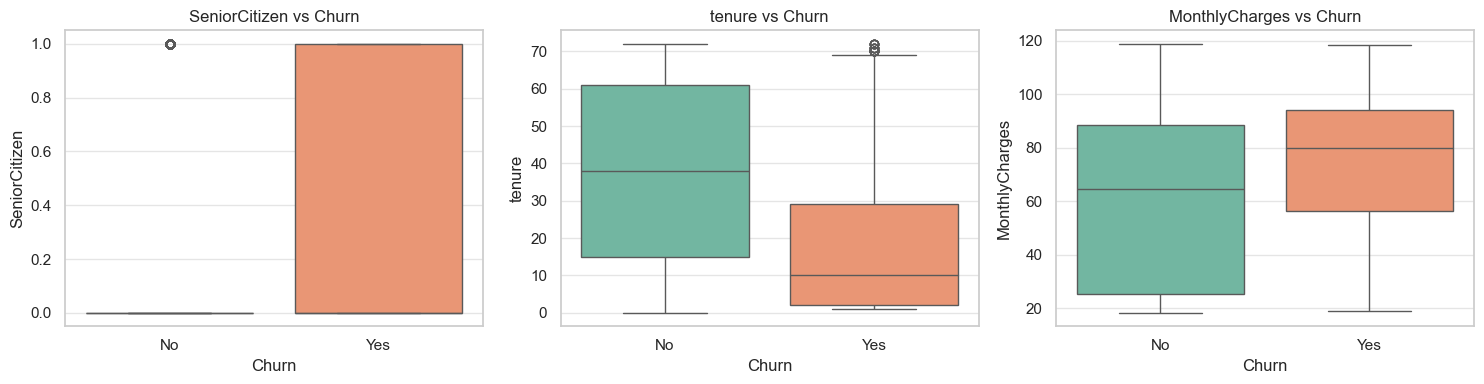

In [13]:
# Cell 8 - How numerical features relate to churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(x='Churn', y=col, hue='Churn',
                data=df, ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

# Key categorical features vs Churn:

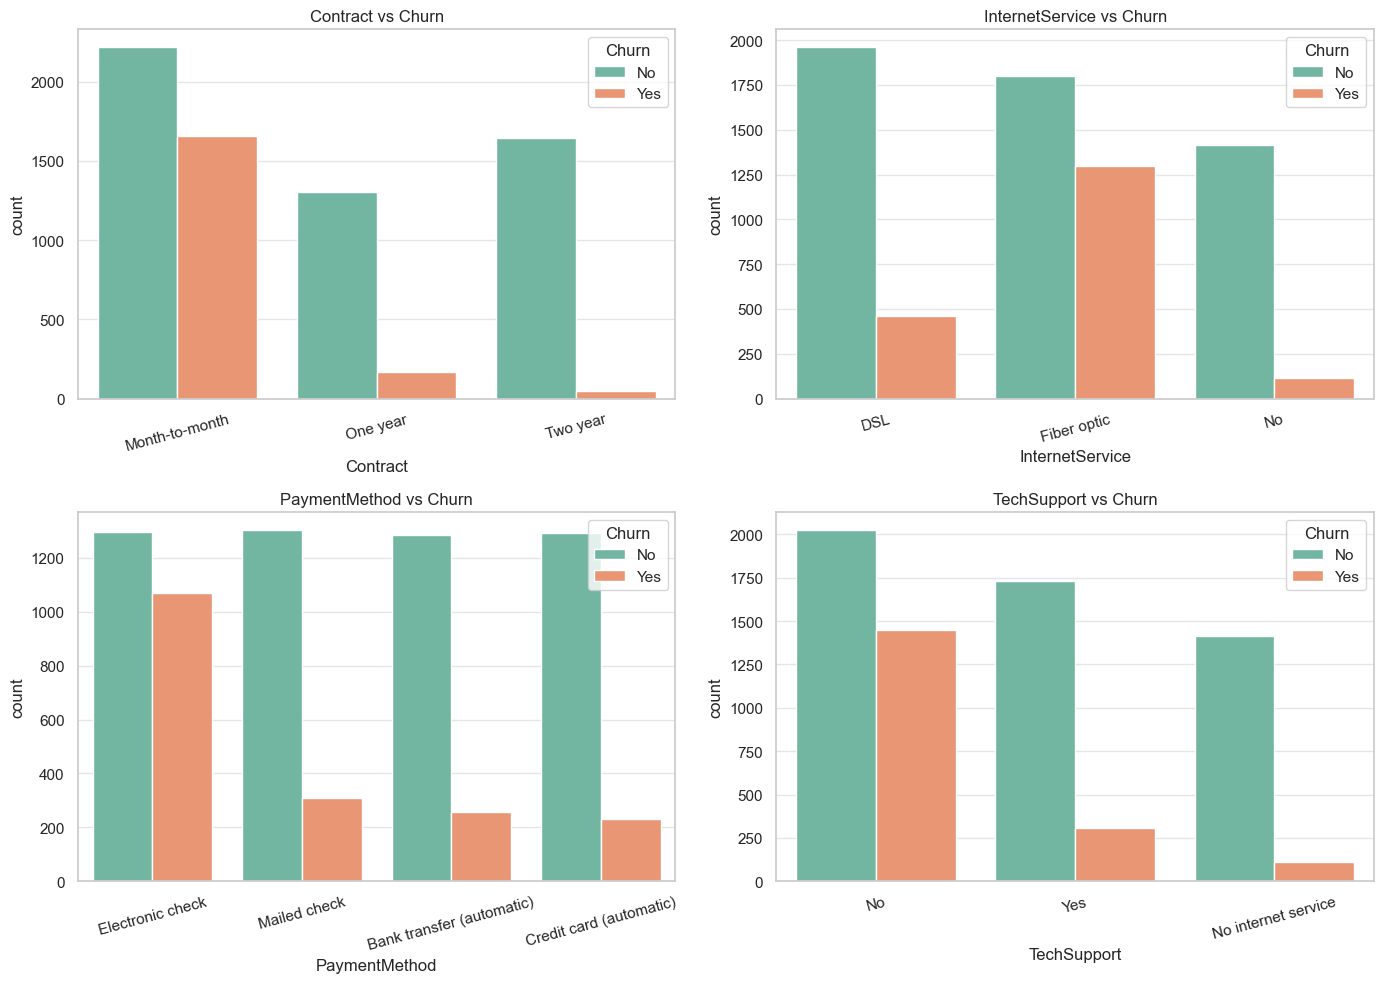

In [14]:
# Cell 9 - Categorical features vs Churn
key_cats = ['Contract', 'InternetService',
            'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), key_cats):
    sns.countplot(x=col, hue='Churn', data=df,
                  ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Churn')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## EDA Summary & Key Findings

### Dataset Overview
- Total records: 7043 customers, 21 columns
- Target variable: Churn (Yes/No)

### Data Quality Issues Found
1. `TotalCharges` stored as `object` dtype instead of `float64`
   - Caused by 11 rows with whitespace " " instead of 0.0
   - These are new customers with tenure = 0
   - Fix: Convert to numeric, replace spaces with 0.0

2. `SeniorCitizen` stored as int64 (0/1)
   - Actually a binary categorical feature
   - Fix: Treat as categorical during preprocessing

### Class Imbalance
- No (did not churn): 5174 → 73%
- Yes (churned): 1869 → 26%
- Dataset is imbalanced → accuracy alone is misleading
- Must use F1-score, Precision, Recall for evaluation

### Key Insights From Plots
- Customers on month-to-month contracts churn the most
- Fiber optic internet service has highest churn rate
- Short tenure customers churn significantly more
- Higher monthly charges correlate with higher churn
- Long tenure customers are loyal — low churn rate

### What Phase 2 Must Handle
- Convert TotalCharges to float64
- Handle 11 whitespace rows
- Scale numerical features (tenure, MonthlyCharges, TotalCharges)
- Encode categorical features (16 columns)
- Encode target variable Churn (Yes/No → 1/0)

# PHASE 2 PROCESSING:

In [15]:
# Test preprocessor functions
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from src.preprocessor import fix_total_charges, encode_target, get_feature_lists
from src.config import RAW_DATA_PATH
import pandas as pd

df = pd.read_csv(RAW_DATA_PATH)

# Test fix_total_charges
df = fix_total_charges(df)
print("TotalCharges dtype after fix:", df['TotalCharges'].dtype)

# Test encode_target
df = encode_target(df)
print("Churn unique values after encoding:", df['Churn'].unique())

# Test get_feature_lists
num_cols, cat_cols = get_feature_lists(df)
print(f"\nNumerical ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

TotalCharges dtype after fix: float64
Churn unique values after encoding: [0 1]

Numerical (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
from src.preprocessor import build_preprocessor
from sklearn.model_selection import train_test_split

# Prepare features and target
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # maintains class ratio in both splits
)

# Build preprocessor
num_cols, cat_cols = get_feature_lists(df)
preprocessor = build_preprocessor(num_cols, cat_cols)

# Fit on training data, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train shape before: {X_train.shape}")
print(f"X_train shape after:  {X_train_processed.shape}")
print(f"X_test shape before:  {X_test.shape}")
print(f"X_test shape after:   {X_test_processed.shape}")

X_train shape before: (5634, 19)
X_train shape after:  (5634, 44)
X_test shape before:  (1409, 19)
X_test shape after:   (1409, 44)


# PIPELINE

In [18]:
from src.pipeline import build_lr_pipeline, build_rf_pipeline

# Build both pipelines
lr_pipeline = build_lr_pipeline(df)
rf_pipeline = build_rf_pipeline(df)

# Inspect pipeline steps
print("Logistic Regression Pipeline:")
print(lr_pipeline.steps)

print("\nRandom Forest Pipeline:")
print(rf_pipeline.steps)

Logistic Regression Pipeline:
[('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMeth

# ─────────────────────────────────────────
# EDA SUMMARY & KEY FINDINGS
# ─────────────────────────────────────────
## 1. Dataset: 7043 rows, 21 columns
## 2. TotalCharges was object dtype → fixed to float64
## 3. 11 whitespace rows → replaced with 0.0
## 4. Churn rate: 26% → imbalanced dataset
## 5. Month-to-month contracts churn the most
##  ─────────────────────────────────────────

In [19]:
print("Logistic Regression Pipeline:")
print(lr_pipeline.steps)

print("\nRandom Forest Pipeline:")
print(rf_pipeline.steps)

Logistic Regression Pipeline:
[('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMeth

# Training Modal

In [20]:
from src.train import (get_lr_param_grid,
                        get_rf_param_grid,
                        train_with_gridsearch,
                        evaluate_model)
from src.pipeline import build_lr_pipeline, build_rf_pipeline

# Build pipelines
lr_pipeline = build_lr_pipeline(df)
rf_pipeline = build_rf_pipeline(df)

# Train Logistic Regression
lr_grid = train_with_gridsearch(
    pipeline=lr_pipeline,
    param_grid=get_lr_param_grid(),
    X_train=X_train,
    y_train=y_train,
    model_name="Logistic Regression"
)

# Train Random Forest
rf_grid = train_with_gridsearch(
    pipeline=rf_pipeline,
    param_grid=get_rf_param_grid(),
    X_train=X_train,
    y_train=y_train,
    model_name="Random Forest"
)


Training Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best Parameters for Logistic Regression:
{'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}

✅ Best CV F1 Score: 0.5971

Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best Parameters for Random Forest:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

✅ Best CV F1 Score: 0.5771


In [21]:
# Evaluate both models on test data
evaluate_model(lr_grid, X_test, y_test,
               "Logistic Regression")

evaluate_model(rf_grid, X_test, y_test,
               "Random Forest")


Evaluation Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Evaluation Report — Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
     Churned       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [22]:
evaluate_model(lr_grid, X_test, y_test,
               "Logistic Regression")


Evaluation Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

